# How the PC Algorithm Works — Step by Step

The **PC algorithm** is the classic method for *causal discovery*: given nothing but a
table of observations, it works out which variables directly cause which. It does this
by testing conditional independence — asking *"does `X` still tell me anything about `Y`
once I account for `Z`?"* — and turning the answers into a graph. Named after its
inventors **P**eter Spirtes and **C**lark Glymour, it is the foundation of the
constraint-based family, including `causal-ts`'s own CDNOTS.

Most tutorials show you PC's *output*. This one shows the work: we run it by hand on
four variables and print the evidence behind every decision.

**What you will learn**

1. Why PC starts from a fully connected graph and deletes, rather than building up
2. What a **separating set** is, and why orientation depends on remembering it
3. How a **collider** leaves a statistical fingerprint that a chain and a fork do not
4. How one oriented arrow **propagates** to orient others (Meek's rules)
5. What PC can and cannot identify, and where finite samples make it unstable

**Prerequisites** — none beyond the idea that two variables can be correlated. For
conceptual background see the [Beginner's Guide](beginers_guide.ipynb); for the
score-based counterpart on identical data, see
[How Score-Based Discovery Works](score_based_step_by_step.ipynb).

> **Setup.** We start with cross-sectional data (one row = one independent observation).
> That keeps the orientation problem visible — in a time series, temporal order already
> orients *lagged* edges, though not contemporaneous ones. Section 10 puts the time axis
> back. Long plotting cells are collapsed; expand them if you want the details.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import itertools

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch

from causalts.ci_tests import ParCorrGPU
from causalts.plotting import corrplot

plt.rcParams.update({"figure.dpi": 110, "savefig.facecolor": "white",
                     "axes.facecolor": "white", "figure.facecolor": "white"})

SEED = 7
ALPHA = 0.05          # significance level: p > ALPHA  =>  "independent"
rng = np.random.default_rng(SEED)

VARS = ["A", "B", "C", "D"]
IDX = {v: i for i, v in enumerate(VARS)}


def pair(u, v):
    """Order-free key for an undirected edge."""
    return frozenset((u, v))

---

## 1. The system we are trying to recover

Four variables: `A` and `B` are independent, both feed into `C`, and `C` feeds into `D`.

```text
    A       B
     ↘     ↙
        C
        ↓
        D
```

| relationship | why it matters |
|---|---|
| `A ⊥ B` | nothing connects them |
| `A → C`, `B → C` | `C` is a **collider** — two arrowheads meet at it |
| `C → D` | an ordinary causal link |

$$A \sim \mathcal{N}(0,1), \quad B \sim \mathcal{N}(0,1), \quad
C = A + B + \varepsilon_C, \quad D = 1.2\,C + \varepsilon_D$$

We generate 2000 samples. **The algorithm never sees the graph above** — only the four
columns of numbers. Our job is to get the graph back.

### When PC's output is a *causal* graph

PC turns conditional-independence facts into a graph. Calling that graph **causal**
takes assumptions the code cannot verify. Here they hold by construction:

| assumption | what it means in this example |
|---|---|
| **Acyclicity** | the data come from a DAG |
| **Markov + faithfulness** | independences in the data match the graph's d-separations |
| **Causal sufficiency** | no hidden common cause, no selection effect |
| **Valid CI test** | partial correlation, because the system is linear Gaussian |

Break one and the output changes meaning: hidden confounding, for instance, calls for
FCI or an explicit deconfounding step rather than plain PC.

> **CPDAGs.** Even with infinite data, observational evidence usually pins down a
> **Markov equivalence class** rather than one DAG. PC reports that class as a CPDAG:
> directed edges are compelled across the class, undirected edges are ties the data
> cannot break.

In [2]:
n = 2000
A = rng.standard_normal(n)
B = rng.standard_normal(n)
C = 1.0 * A + 1.0 * B + rng.standard_normal(n)
D = 1.2 * C + rng.standard_normal(n)

X = np.column_stack([A, B, C, D])
df = pd.DataFrame(X, columns=VARS)

TRUE_ARROWS = [("A", "C"), ("B", "C"), ("C", "D")]

print(f"{n} samples, {len(VARS)} variables")
df.head()

2000 samples, 4 variables


,A,B,C,D
0,0.001230,-0.365636,0.386308,-0.666422
1,0.298746,0.341812,1.710283,2.227463
2,-0.274138,-0.165342,-1.429386,0.338368
3,-0.890592,-0.889232,-0.512337,-2.041010
4,-0.454671,0.787681,-0.141376,0.449296


### How to read the figures

Every step gets its own frame, in one consistent format:

| what you see | what it means |
|---|---|
| **solid dark line** | edge currently in the graph, direction not yet known |
| **dashed grey line** | edge deleted on *this* step (shown once, then gone) |
| **blue arrow** | direction decided on *this* step |
| **dark arrow** | direction decided earlier |
| **red ring** | the variables being tested right now |
| text on an edge | the p-value that decided its fate |

In [3]:
NODE_POS = {"A": (0.0, 1.0), "B": (2.0, 1.0), "C": (1.0, 0.0), "D": (1.0, -1.15)}

INK, GREY, BLUE, RED = "#22262e", "#c3c8d1", "#2c6fbb", "#d1495b"


def draw_state(edges=(), arrows=(), new_arrows=(), removed=(), labels=None,
               highlight=(), title=None, caption=None, ax=None):
    """Draw one frame of the algorithm's state (see the legend above)."""
    labels = labels or {}
    if ax is None:
        _, ax = plt.subplots(figsize=(3.4, 3.4))
    ax.set_xlim(-0.65, 2.65)
    ax.set_ylim(-1.95, 1.45)
    ax.set_aspect("equal")
    ax.axis("off")

    def seg(u, v, color, style, width, arrow, z=1):
        ax.add_patch(FancyArrowPatch(
            NODE_POS[u], NODE_POS[v], arrowstyle="-|>" if arrow else "-",
            mutation_scale=16, linewidth=width, linestyle=style, color=color,
            shrinkA=17, shrinkB=17, zorder=z))

    for u, v in removed:
        seg(u, v, GREY, (0, (4, 3)), 1.6, False)
    for u, v in edges:
        seg(u, v, INK, "-", 1.9, False)
    for u, v in arrows:
        seg(u, v, INK, "-", 1.9, True)
    for u, v in new_arrows:
        seg(u, v, BLUE, "-", 3.0, True, z=3)

    cx = np.mean([p[0] for p in NODE_POS.values()])
    cy = np.mean([p[1] for p in NODE_POS.values()])
    for key, text in labels.items():
        u, v = tuple(key)
        (x1, y1), (x2, y2) = NODE_POS[u], NODE_POS[v]
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        dx, dy = x2 - x1, y2 - y1
        nrm = np.hypot(dx, dy)
        nx_, ny_ = -dy / nrm, dx / nrm             # unit normal to the edge
        s = 1.0 if (nx_ * (mx - cx) + ny_ * (my - cy)) >= 0 else -1.0
        ax.text(mx + s * nx_ * 0.30, my + s * ny_ * 0.30,
                text, ha="center", va="center", fontsize=7.5, color="#4a5160",
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85),
                zorder=7)

    for name, (x, y) in NODE_POS.items():
        hot = name in highlight
        ax.add_patch(mpatches.Circle((x, y), 0.26, facecolor="white",
                                     edgecolor=RED if hot else INK,
                                     linewidth=2.6 if hot else 1.6, zorder=5))
        ax.text(x, y, name, ha="center", va="center", fontsize=12,
                weight="bold", zorder=6)

    if title:
        ax.set_title(title, fontsize=10.5, weight="bold", color=INK, pad=8)
    if caption:
        ax.text(1.0, -1.82, caption, ha="center", va="center",
                fontsize=8, color="#6b7280")
    return ax

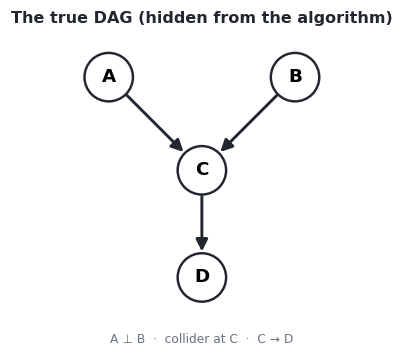

In [4]:
# The answer key. We plot it once, then put it away until the very end.
draw_state(arrows=TRUE_ARROWS, title="The true DAG (hidden from the algorithm)",
           caption="A ⊥ B  ·  collider at C  ·  C → D")
plt.tight_layout()
plt.show()

### Why this is hard: everything looks related

Start with the plain correlation matrix. `A` and `D` have no direct link, yet they
correlate at ~0.5 — because `A` influences `D` *through* `C`. Every off-diagonal cell
except `A`–`B` is large.

Correlation alone cannot separate direct links from inherited ones. That is the problem
PC exists to solve.

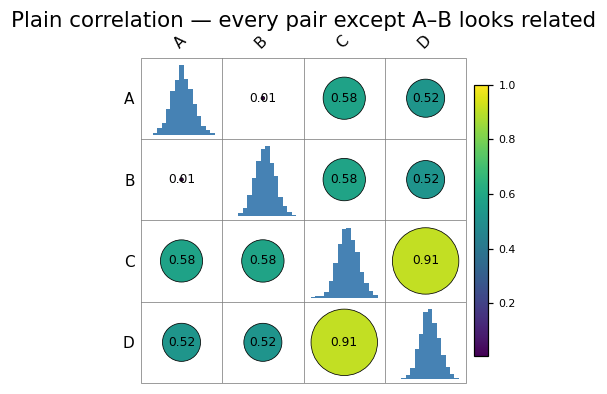

corr(A, D) = 0.524   <- but there is NO edge A → D in the true graph


In [5]:
corr = df.corr().values

# `corrplot` is causal-ts's own correlation display: circle area encodes |r|,
# colour encodes magnitude, and the diagonal carries each variable's marginal
# distribution. See the plotting guide for the full set of glyphs and layouts.
fig, ax = plt.subplots(figsize=(4.6, 4.0))
corrplot(df, method="circle", diag="hist", add_coef=True,
         title="Plain correlation — every pair except A–B looks related",
         fig_ax=(fig, ax))
plt.show()

print(f"corr(A, D) = {corr[0, 3]:.3f}   <- but there is NO edge A → D in the true graph")


---

## 2. PC's strategy: assume everything, then delete

PC runs in two stages:

| stage | question it asks | output |
|---|---|---|
| **Skeleton** (§3–5) | which pairs are *directly* connected? | undirected graph |
| **Orientation** (§7–8) | which way do the arrows point? | partly or fully directed graph |

The skeleton stage starts from the **complete graph** — every variable joined to every
other, 6 edges for 4 variables — and deletes an edge when it finds evidence
against it.

> **The deletion rule.** Delete the edge between `X` and `Y` if there is **any** set `S`
> of other variables that makes them independent once held fixed: `X ⊥ Y | S`.

The intuition: a *direct* link cannot be broken by a third variable. So if some `S` does break the
dependence, the link was never direct — it ran through `S`. (Formally this is
d-separation: variables adjacent in a faithful DAG cannot be separated by any set.)

PC tries the sets `S` smallest-first — `{}`, then single variables, then pairs — because
small sets are cheaper and, on finite data, more reliable.

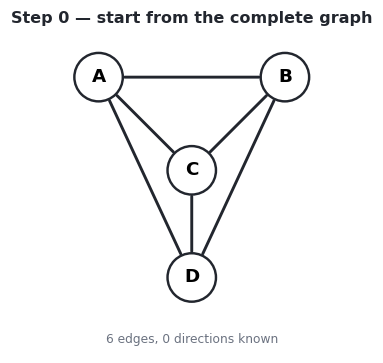

In [6]:
ALL_PAIRS = [(u, v) for u, v in itertools.combinations(VARS, 2)]

draw_state(edges=ALL_PAIRS, title="Step 0 — start from the complete graph",
           caption="6 edges, 0 directions known")
plt.tight_layout()
plt.show()

### The test we will use

To ask *"are `X` and `Y` independent given `S`?"* we need a **conditional independence
(CI) test**. We use `causal-ts`'s `ParCorrGPU` — partial correlation with a Fisher
z-transform — because the data are linear Gaussian. Nonlinear data needs a different
test ([comparison here](ci_test_comparison.ipynb)); the search logic is unchanged.

The null hypothesis is `X ⊥ Y | S`. A p-value says how surprising the test statistic
would be *if that null held*. It is **not** the probability that independence is true.
At `alpha = 0.05`, PC acts on it like this:

| test result | what PC does |
|---|---|
| `p ≤ 0.05` | reject independence → **keep** the edge, for now |
| `p > 0.05` | fail to reject → **mark the edge for deletion** and record `S` |

A small p-value does not prove a direct causal link, and a large one does not prove
independence. These are operational decisions made under uncertainty.

"Mark for deletion" rather than "delete" is deliberate: PC-stable finishes every test at
the current depth before touching the graph. Section 4 shows why that matters.

The recorded set `S` is the **separating set**, `sepset(X, Y)`. It looks like bookkeeping
now; Section 7 turns it into orientation.

In [7]:
ci = ParCorrGPU(X, device="cpu")


def test(x, y, S=()):
    """p-value for  x ⊥ y | S,  with x, y, S given as variable NAMES."""
    p, _ = ci(IDX[x], IDX[y], [IDX[s] for s in S])
    return float(p)


def show(results):
    """Print a test table: (x, y, S, p, verdict) rows."""
    print(f"{'test':<18}{'p-value':>12}   verdict")
    print("-" * 52)
    for x, y, S, p in results:
        cond = "{" + ", ".join(S) + "}" if S else "{}"
        verdict = "REMOVE edge" if p > ALPHA else "keep"
        print(f"{x} ⊥ {y} | {cond:<8}{p:>12.3g}   {verdict}")


# sanity check: the test agrees with plain correlation when S is empty
print(f"test(A, D)            p = {test('A', 'D'):.3g}")
print(f"pearson corr(A, D)      = {corr[0, 3]:.3f}")

test(A, D)            p = 2.56e-141
pearson corr(A, D)      = 0.524


---

## 3. Depth 0 — condition on nothing

`S = {}`. Six pairs, six tests. This is just "are these two correlated at all?"

**Predict before you run:** which of the six do you expect to survive? Remember that
`A → C → D` means `A` and `D` *are* correlated even though no edge joins them.

In [8]:
sepset = {}                       # pair -> the set S that separated it
edges = set(map(lambda e: pair(*e), ALL_PAIRS))

depth0 = [(x, y, (), test(x, y, ())) for x, y in ALL_PAIRS]
show(depth0)

removed0 = []
for x, y, S, p in depth0:
    if p > ALPHA:
        edges.discard(pair(x, y))
        sepset[pair(x, y)] = set(S)
        removed0.append((x, y))

print(f"\n{len(depth0)} tests run, {len(removed0)} edge(s) removed, "
      f"{len(edges)} remain")
print("separating sets so far:",
      {f"{'-'.join(sorted(k))}": (set(v) or "{}") for k, v in sepset.items()})

test                   p-value   verdict
----------------------------------------------------
A ⊥ B | {}             0.736   REMOVE edge
A ⊥ C | {}         1.65e-179   keep
A ⊥ D | {}         2.56e-141   keep
B ⊥ C | {}         2.33e-181   keep
B ⊥ D | {}         8.87e-141   keep
C ⊥ D | {}                 0   keep

6 tests run, 1 edge(s) removed, 5 remain
separating sets so far: {'A-B': '{}'}


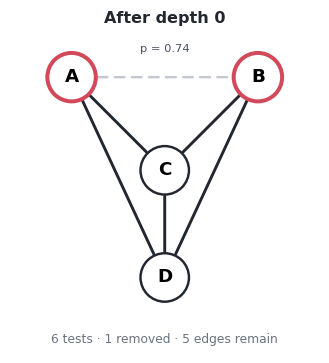

In [9]:
draw_state(edges=[tuple(e) for e in edges], removed=removed0,
           labels={pair("A", "B"): f"p = {test('A','B'):.2f}"},
           highlight={"A", "B"},
           title="After depth 0",
           caption="6 tests · 1 removed · 5 edges remain")
plt.tight_layout()
plt.show()

**In plain words.** Only `A`–`B` fell: at p = 0.74 we fail to reject marginal
independence, so PC removes the edge. The other five strongly reject it and survive.

Note what we did *not* learn. `A`–`D` survived at p ≈ `2.6e-141`, which looks like
overwhelming evidence of a direct link. It is not — `A` and `D` correlate purely because
`A → C → D`. Depth 0 cannot see the difference; depth 1 can.

We also recorded `sepset(A, B) = {}`. That fact does nothing right now. In Section 7 it
orients half the graph.

> A p-value printed as `0` here and below is numerical underflow — smaller than the
> display can represent, not a literal zero.

---

## 4. Depth 1 — condition on one variable at a time

Now `S` is a single variable. For each surviving edge `X`–`Y`, the candidate blockers are
the neighbours of `X` and of `Y`.

Here the two versions of PC part ways, and the difference matters:

| | **original PC** | **PC-stable** (our default) |
|---|---|---|
| adjacency sets | updated the moment an edge dies | **frozen** for the whole depth |
| on finding a separator | stop testing that pair | **test every eligible blocker anyway** |
| when edges are removed | immediately, mid-sweep | **all at once, at the end of the depth** |
| result | can depend on the order edges are visited | **order-independent** |

Deleting an edge mid-sweep shrinks the neighbour sets, so every pair tested afterwards
faces a different candidate list — that is exactly how visit order leaks into the answer.
PC-stable pays for a few extra tests and buys a deterministic skeleton.

**We follow PC-stable below**

In [10]:
def neighbours(edge_set, v):
    return {w for e in edge_set if v in e for w in e if w != v}


depth1 = []
for e in sorted(edges, key=lambda s: sorted(s)):
    x, y = sorted(e)
    cands = (neighbours(edges, x) | neighbours(edges, y)) - {x, y}
    for s in sorted(cands):
        depth1.append((x, y, (s,), test(x, y, (s,))))

show(depth1)

test                   p-value   verdict
----------------------------------------------------
A ⊥ C | {B}        3.05e-302   keep
A ⊥ C | {D}         4.41e-40   keep
A ⊥ D | {B}        5.93e-204   keep
A ⊥ D | {C}            0.806   REMOVE edge
B ⊥ C | {A}        4.33e-304   keep
B ⊥ C | {D}         1.48e-42   keep
B ⊥ D | {A}        2.05e-203   keep
B ⊥ D | {C}            0.517   REMOVE edge
C ⊥ D | {A}                0   keep
C ⊥ D | {B}                0   keep


In [11]:
# PC-stable: removals are applied only AFTER every test at this depth has run.
# The candidate lists above were therefore all computed from one frozen adjacency.
removed1 = []
for x, y, S, p in depth1:
    if p > ALPHA and pair(x, y) in edges:
        edges.discard(pair(x, y))
        sepset[pair(x, y)] = set(S)
        removed1.append((x, y))

print(f"{len(depth1)} tests run, {len(removed1)} edge(s) removed, "
      f"{len(edges)} remain\n")
for k, v in sepset.items():
    print(f"  sepset({', '.join(sorted(k))}) = " + ("{" + ", ".join(sorted(v)) + "}"))

10 tests run, 2 edge(s) removed, 3 remain

  sepset(A, B) = {}
  sepset(A, D) = {C}
  sepset(B, D) = {C}


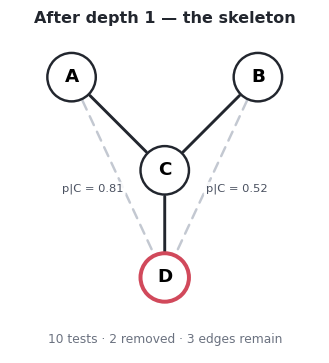

In [12]:
draw_state(edges=[tuple(e) for e in edges], removed=removed1,
           labels={pair("A", "D"): f"p|C = {test('A','D',('C',)):.2f}",
                   pair("B", "D"): f"p|C = {test('B','D',('C',)):.2f}"},
           highlight={"D"},
           title="After depth 1 — the skeleton",
           caption=f"{len(depth1)} tests · 2 removed · 3 edges remain")
plt.tight_layout()
plt.show()

**In plain words.** Two edges fell — exactly the two "shortcut" edges:

- `A`–`D` died given `C`: p jumped from `2.6e-141` to **0.81**. Hold `C` fixed and `A`
  says nothing more about `D`. That is the signature of the path `A → C → D`.
- `B`–`D` died given `C`, for the same reason.

Meanwhile `A`–`C` survived conditioning on `B` (p ≈ `3e-302`) and on `D` (p ≈ `4e-40`).
No single variable breaks it, because it is a real direct link.

Both dead edges got `sepset = {C}`. Hold on to that too.

> **Why the p-value moved so far.** Conditioning on `C` means comparing observations that
> share the same value of `C`. Among those, `A` still varies and `D` still varies — but
> their variation is no longer coupled, because the only channel between them ran through
> `C`, and we just froze it.

---

## 5. Depth 2 — the last round, and the stopping rule

Now `S` holds two variables. Which edges even qualify for such a test? After depth 1 the
graph is a star centred on `C`, so the candidate blockers are thin on the ground:

- edge `A–C`: the other variables touching either endpoint are `{B, D}` — two, so a
  depth-2 test is possible
- edge `B–C`: candidates `{A, D}`
- edge `C–D`: candidates `{A, B}`

Three tests. Then PC checks whether a depth-3 test is possible anywhere, finds it is not,
and stops.

In [13]:
print("adjacency after depth 1:")
for v in VARS:
    print(f"  {v}: {sorted(neighbours(edges, v))}")
print()

depth2 = []
for e in sorted(edges, key=lambda s: sorted(s)):
    x, y = sorted(e)
    cands = sorted((neighbours(edges, x) | neighbours(edges, y)) - {x, y})
    print(f"  edge {x} – {y}: candidate blockers {cands}")
    depth2 += [(x, y, S, test(x, y, S)) for S in itertools.combinations(cands, 2)]

print()
show(depth2)

removed2 = [(x, y) for x, y, S, p in depth2 if p > ALPHA]
print(f"\n{len(depth2)} tests run, {len(removed2)} edge(s) removed, "
      f"{len(edges)} remain")

adjacency after depth 1:
  A: ['C']
  B: ['C']
  C: ['A', 'B', 'D']
  D: ['C']

  edge A – C: candidate blockers ['B', 'D']
  edge B – C: candidate blockers ['A', 'D']
  edge C – D: candidate blockers ['A', 'B']

test                   p-value   verdict
----------------------------------------------------
A ⊥ C | {B, D}     2.13e-100   keep
B ⊥ C | {A, D}     7.29e-103   keep
C ⊥ D | {A, B}             0   keep

3 tests run, 0 edge(s) removed, 3 remain


In [14]:
biggest = max(len((neighbours(edges, x) | neighbours(edges, y)) - {x, y})
              for e in edges for x, y in [sorted(e)])
print(f"largest candidate set still available: {biggest}")
print(f"depth 3 would need 3  ->  STOP. The skeleton is final: "
      f"{sorted(tuple(sorted(e)) for e in edges)}")

# What did restricting to neighbours buy us? Compare against testing every subset blindly.
n_stable = len(depth0) + len(depth1) + len(depth2)
n_blind = sum(1 for x, y in ALL_PAIRS for k in range(3)
              for _ in itertools.combinations([v for v in VARS if v not in (x, y)], k))
print(f"\nCI tests run by PC-stable:   {n_stable}")
print(f"CI tests run by brute force: {n_blind}")
print("PC-stable restricts conditioning sets to current neighbours. Blind exhaustive")
print("conditioning needs 2^(d-2) subsets per pair -- 262,144 per pair at d = 20.")
print("That restriction is what makes constraint-based discovery tractable at all.")

largest candidate set still available: 2
depth 3 would need 3  ->  STOP. The skeleton is final: [('A', 'C'), ('B', 'C'), ('C', 'D')]

CI tests run by PC-stable:   19
CI tests run by brute force: 24
PC-stable restricts conditioning sets to current neighbours. Blind exhaustive
conditioning needs 2^(d-2) subsets per pair -- 262,144 per pair at d = 20.
That restriction is what makes constraint-based discovery tractable at all.


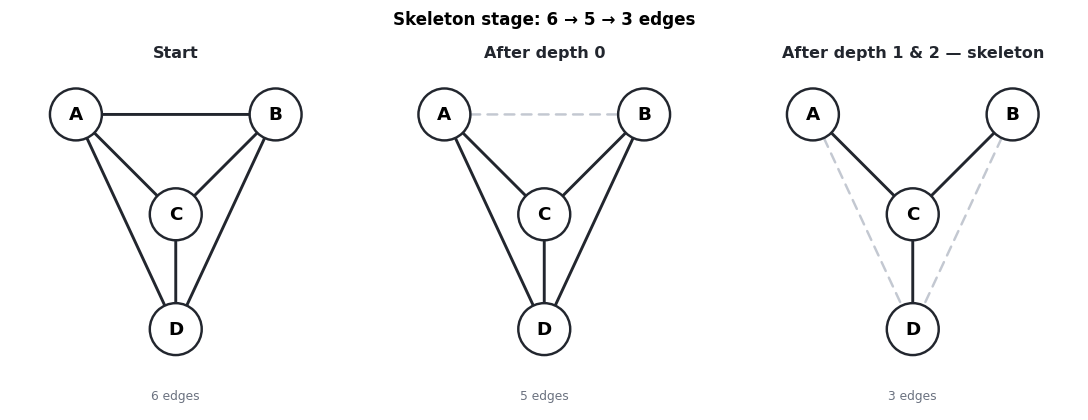

In [15]:
# Filmstrip: the whole skeleton stage in one row.
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.7))
draw_state(edges=ALL_PAIRS, title="Start", caption="6 edges", ax=axes[0])
draw_state(edges=[e for e in ALL_PAIRS if set(e) != {"A", "B"}],
           removed=[("A", "B")], title="After depth 0", caption="5 edges",
           ax=axes[1])
draw_state(edges=[tuple(e) for e in edges], removed=[("A", "D"), ("B", "D")],
           title="After depth 1 & 2 — skeleton", caption="3 edges", ax=axes[2])
fig.suptitle("Skeleton stage: 6 → 5 → 3 edges", fontsize=11, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

> ### Recap — skeleton stage
>
> - Started with 6 edges, ended with 3: `A–C`, `B–C`, `C–D` — the correct skeleton of the
>   true DAG.
> - PC-stable evaluated 6 + 10 + 3 = 19 distinct CI statements and recorded 3 separating
>   sets: `sepset(A,B) = {}`, `sepset(A,D) = {C}`, `sepset(B,D) = {C}`.
> - **We still have zero arrows.** Every edge is undirected. That is the next stage.

---

## 6. The obstacle: three structures, two identical footprints

Before orienting anything, you have to appreciate *why orientation is hard*.

Take three variables `X`, `Z`, `Y` and consider the three ways they can be wired. The two
right-hand columns are all PC ever gets to observe:

| structure | name | what it means | `X` vs `Y` | `X` vs `Y` given `Z` |
|---|---|---|---|---|
| `X → Z → Y` | **chain** | `X` causes `Y`, but only through `Z` | dependent | **independent** |
| `X ← Z → Y` | **fork** | `Z` is a common cause of both | dependent | **independent** |
| `X → Z ← Y` | **collider** | `X` and `Y` both cause `Z`, and are unrelated | **independent** | dependent |

**Chain and fork are indistinguishable.** In both, all three variables are correlated, and
holding `Z` fixed severs the association between `X` and `Y` — because in both, `Z` sits on
the only path connecting them. Two different causal stories, one observable footprint. No
CI test can prefer one over the other.

**The collider inverts both answers.** `X` and `Y` start out *independent* — nothing
connects them. Conditioning on their common **effect** `Z` makes them *dependent*. That is
the one pattern neither chain nor fork can produce, which is why the collider is the
structure PC can actually recognise.

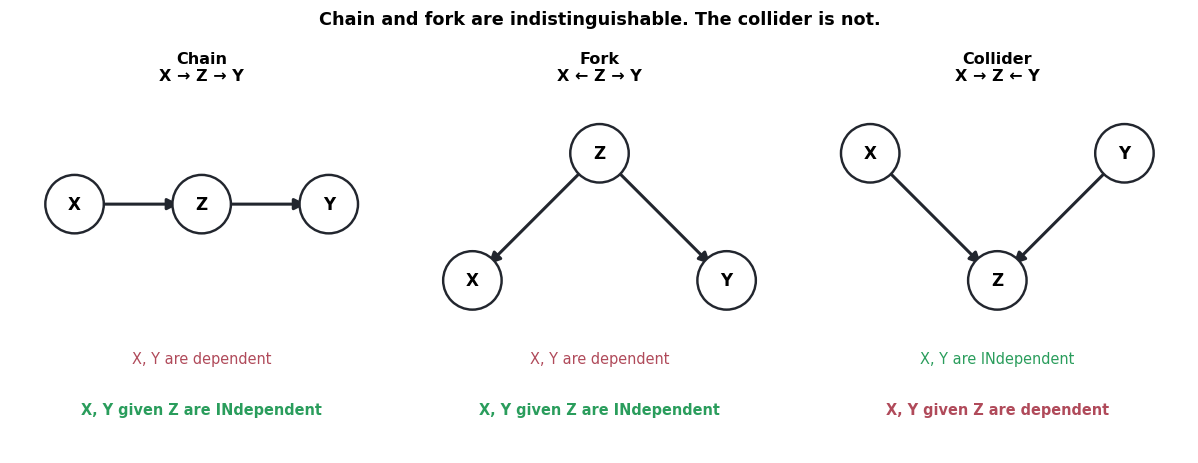

In [16]:
struct_specs = [
    ("Chain\nX → Z → Y", [("X", "Z"), ("Z", "Y")],
     {"X": (0, 0.6), "Z": (1, 0.6), "Y": (2, 0.6)}),
    ("Fork\nX ← Z → Y", [("Z", "X"), ("Z", "Y")],
     {"X": (0, 0), "Z": (1, 1.0), "Y": (2, 0)}),
    ("Collider\nX → Z ← Y", [("X", "Z"), ("Y", "Z")],
     {"X": (0, 1.0), "Y": (2, 1.0), "Z": (1, 0)}),
]
verdicts = [
    ("dependent", "INdependent"),
    ("dependent", "INdependent"),
    ("INdependent", "dependent"),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 4.1))
for ax, (title, arcs, pos), (v0, v1) in zip(axes, struct_specs, verdicts):
    ax.set_xlim(-0.5, 2.5); ax.set_ylim(-1.35, 1.5)
    ax.set_aspect("equal"); ax.axis("off")
    for u, v in arcs:
        ax.add_patch(FancyArrowPatch(pos[u], pos[v], arrowstyle="-|>",
                                     mutation_scale=15, linewidth=2, color=INK,
                                     shrinkA=15, shrinkB=15))
    for nme, (x, y) in pos.items():
        ax.add_patch(mpatches.Circle((x, y), 0.23, facecolor="white",
                                     edgecolor=INK, linewidth=1.6, zorder=5))
        ax.text(x, y, nme, ha="center", va="center", fontsize=11,
                weight="bold", zorder=6)
    ax.set_title(title, fontsize=10.5, weight="bold", pad=6)
    col = "#2a9d5c" if v0.startswith("IN") else "#b04a5a"
    ax.text(1, -0.65, f"X, Y are {v0}", ha="center", fontsize=9.5, color=col)
    col = "#2a9d5c" if v1.startswith("IN") else "#b04a5a"
    ax.text(1, -1.05, f"X, Y given Z are {v1}", ha="center", fontsize=9.5,
            color=col, weight="bold")
fig.suptitle("Chain and fork are indistinguishable. The collider is not.",
             fontsize=11.5, weight="bold", y=1.04)
plt.tight_layout()
plt.show()

That is both the good news and the bad news of constraint-based discovery.

**The bad news.** Because chain and fork share a footprint, an isolated relation like
`C–D` cannot be oriented from CI evidence alone. PC therefore returns a **Markov
equivalence class** (a CPDAG) rather than inventing a single DAG. Interventions, temporal
order, background knowledge, or stronger model assumptions can break some of those ties.

**The good news.** Unshielded colliders *are* detectable, and each one you find pins down
arrows that can force others through pure graph logic. That is Sections 7 and 8.

The [score-based companion](score_based_step_by_step.ipynb) reaches this same boundary
by a completely different route.

---

## 7. Orientation, part 1 — find the colliders

The central orientation rule:

> **Collider rule.** Take an *unshielded triple* `X – Z – Y`: `X`–`Z` and `Z`–`Y` are
> adjacent, but `X`–`Y` is not. If `Z ∉ sepset(X, Y)`, orient it `X → Z ← Y`.

**Why it works.** `X` and `Y` became non-adjacent because some set `S` separated them.
In a chain or fork through `Z`, conditioning on `Z` is what blocks the path — so `Z`
would appear in that separating set. At a collider the path is already blocked *without*
conditioning on `Z`; conditioning on it would open the path instead.

Our skeleton contains **three** unshielded triples, and only one passes the test:

| triple | separating set | contains `Z`? | verdict |
|---|---|---|---|
| `A – C – B` | `sepset(A,B) = {}` | no | **collider** → `A → C ← B` |
| `A – C – D` | `sepset(A,D) = {C}` | yes | chain or fork — leave it |
| `B – C – D` | `sepset(B,D) = {C}` | yes | chain or fork — leave it |

**Predict before you run.** We know `A ⊥ B` marginally, at p = 0.74. What happens to that
p-value if we condition on their common child `C`?

In [17]:
p_ab_none = test("A", "B", ())
p_ab_c = test("A", "B", ("C",))
p_ad_none = test("A", "D", ())
p_ad_c = test("A", "D", ("C",))

print(f"A ⊥ B | {{}}    p = {p_ab_none:>10.3g}   independent")
print(f"A ⊥ B | {{C}}   p = {p_ab_c:>10.3g}   DEPENDENT  <- conditioning CREATED it")
print()
print(f"A ⊥ D | {{}}    p = {p_ad_none:>10.3g}   dependent")
print(f"A ⊥ D | {{C}}   p = {p_ad_c:>10.3g}   INDEPENDENT <- conditioning DESTROYED it")

A ⊥ B | {}    p =      0.736   independent
A ⊥ B | {C}   p =  6.24e-125   DEPENDENT  <- conditioning CREATED it

A ⊥ D | {}    p =  2.56e-141   dependent
A ⊥ D | {C}   p =      0.806   INDEPENDENT <- conditioning DESTROYED it


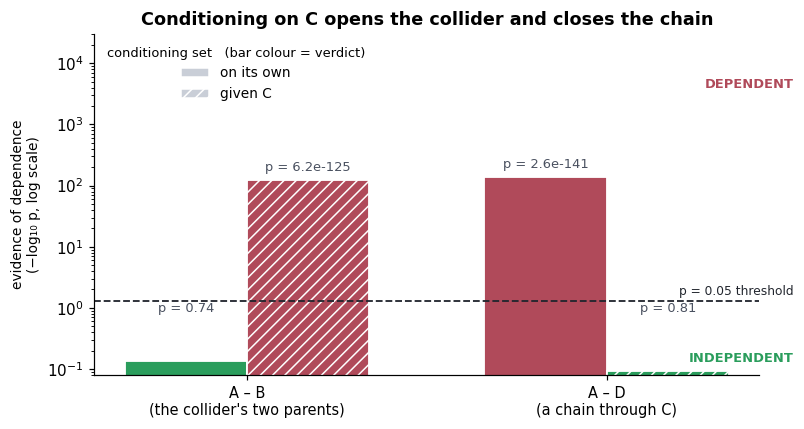

In [18]:
GREEN, MAROON = "#2a9d5c", "#b04a5a"


def evidence(p):
    return -np.log10(max(p, 1e-320))


groups = [("A – B\n(the collider's two parents)", p_ab_none, p_ab_c),
          ("A – D\n(a chain through C)", p_ad_none, p_ad_c)]

fig, ax = plt.subplots(figsize=(7.4, 4.0))
xs = np.arange(2)
w = 0.34
for k, (off, key, lab) in enumerate([(-w / 2, 1, "on its own"),
                                     (w / 2, 2, "given C")]):
    vals = [evidence(g[key]) for g in groups]
    ps = [g[key] for g in groups]
    cols = [GREEN if v < evidence(ALPHA) else MAROON for v in vals]
    bars = ax.bar(xs + off, vals, width=w, color=cols,
                  edgecolor="white", linewidth=1.2,
                  hatch="" if k == 0 else "///", label=lab)
    for b, v, p in zip(bars, vals, ps):
        ax.text(b.get_x() + b.get_width() / 2, max(v, 0.6) * 1.4,
                f"p = {p:.2g}", ha="center", fontsize=8.5, color="#4a5160")

ax.set_yscale("log")
ax.set_ylim(0.08, 3e4)
ax.axhline(evidence(ALPHA), color=INK, linestyle="--", linewidth=1.2)
ax.text(1.52, evidence(ALPHA) * 1.25, "p = 0.05 threshold", fontsize=8,
        ha="right", color=INK)
ax.text(1.52, 4e3, "DEPENDENT", fontsize=8.5, ha="right", color=MAROON,
        weight="bold")
ax.text(1.52, 0.13, "INDEPENDENT", fontsize=8.5, ha="right", color=GREEN,
        weight="bold")
ax.set_xticks(xs, [g[0] for g in groups], fontsize=9.5)
ax.set_ylabel("evidence of dependence\n(−log₁₀ p, log scale)", fontsize=9)
ax.set_title("Conditioning on C opens the collider and closes the chain",
             fontsize=11.5, weight="bold")
ax.legend(handles=[mpatches.Patch(facecolor="#c9ced7", edgecolor="white",
                                  label="on its own"),
                   mpatches.Patch(facecolor="#c9ced7", edgecolor="white",
                                  hatch="///", label="given C")],
          title="conditioning set   (bar colour = verdict)", fontsize=9,
          title_fontsize=8.5, loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Conditioning on `C` did **opposite things** to the two pairs:

- `A` and `B` went from independent to *massively* dependent. Once you know `C`, learning
  `A` tells you a lot about `B` — if `C` is high and `A` turns out low, `B` must have been
  high. This is **explaining away**, and it is what a collider does.
- `A` and `D` went the other way, from dependent to independent. That is a chain or fork.

That sign flip is the entire orientation signal. Everything below is bookkeeping.

In [19]:
def unshielded_triples(edge_set):
    out = []
    for z in VARS:
        nb = sorted(neighbours(edge_set, z))
        for x, y in itertools.combinations(nb, 2):
            if pair(x, y) not in edge_set:
                out.append((x, z, y))
    return out


arrows = set()
print("unshielded triples in the skeleton:", unshielded_triples(edges), "\n")

for x, z, y in unshielded_triples(edges):
    S = sepset.get(pair(x, y), set())
    inside = z in S
    print(f"  triple {x} – {z} – {y}:  sepset({x},{y}) = "
          + ("{" + ", ".join(sorted(S)) + "}")
          + f"   contains {z}? {'yes' if inside else 'NO'}"
          + ("   -> chain or fork, leave it" if inside
             else f"   -> COLLIDER: {x} → {z} ← {y}"))
    if not inside:
        arrows |= {(x, z), (y, z)}

print("\noriented so far:", sorted(arrows))

unshielded triples in the skeleton: [('A', 'C', 'B'), ('A', 'C', 'D'), ('B', 'C', 'D')] 

  triple A – C – B:  sepset(A,B) = {}   contains C? NO   -> COLLIDER: A → C ← B
  triple A – C – D:  sepset(A,D) = {C}   contains C? yes   -> chain or fork, leave it
  triple B – C – D:  sepset(B,D) = {C}   contains C? yes   -> chain or fork, leave it

oriented so far: [('A', 'C'), ('B', 'C')]


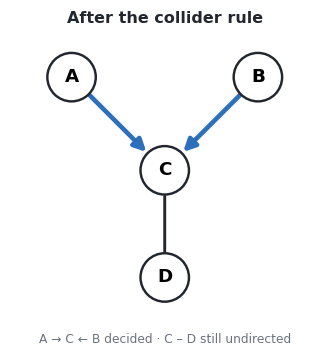

In [20]:
draw_state(edges=[("C", "D")], new_arrows=sorted(arrows),
           title="After the collider rule",
           caption="A → C ← B decided · C – D still undirected")
plt.tight_layout()
plt.show()

---

## 8. Orientation, part 2 — let the arrows propagate

One edge is left: `C–D`. No collider rule applies to it, but the arrows we already have
*constrain* it.

Suppose `C–D` were really `C ← D`. Then `A → C ← D` would be a second collider on the
unshielded triple `A – C – D` — and a collider there implies `A` and `D` are *dependent*
given `C`. We tested exactly that and failed to reject independence at p = 0.81, which
is why `C` landed in `sepset(A, D)` and the edge was deleted in the first place.
Orienting `C ← D` would contradict the evidence that built this skeleton.

So `C ← D` is ruled out, and only `C → D` remains.

That argument is **Meek's Rule 1**, and it generalises:

> **R1.** If `a → b` and `b – c` and `a`, `c` are not adjacent, orient `b → c`.
> *(Otherwise `a → b ← c` would be a collider — and we would already have found it.)*

Two further rules cover the other ways an orientation can be forced. The `meek()` routine
in `causalts/cdnots/meek.py` applies all three repeatedly until nothing changes.

In [21]:
def meek_r1(edge_set, arrow_set):
    """Meek R1: a → b, b – c, a and c non-adjacent  =>  b → c."""
    new = set()
    for a, b in sorted(arrow_set):
        for c in sorted(neighbours(edge_set, b)):
            if c == a or (b, c) in arrow_set | new or (c, b) in arrow_set:
                continue
            if pair(a, c) not in edge_set:
                new.add((b, c))
                print(f"  R1: {a} → {b} and {b} – {c}, with {a} and {c} "
                      f"non-adjacent   =>   {b} → {c}")
    return new


print("applying Meek's rules:")
new_arrows = meek_r1(edges, arrows)
arrows |= new_arrows
print(f"\nfinal arrow set: {sorted(arrows)}")

applying Meek's rules:
  R1: A → C and C – D, with A and D non-adjacent   =>   C → D

final arrow set: [('A', 'C'), ('B', 'C'), ('C', 'D')]


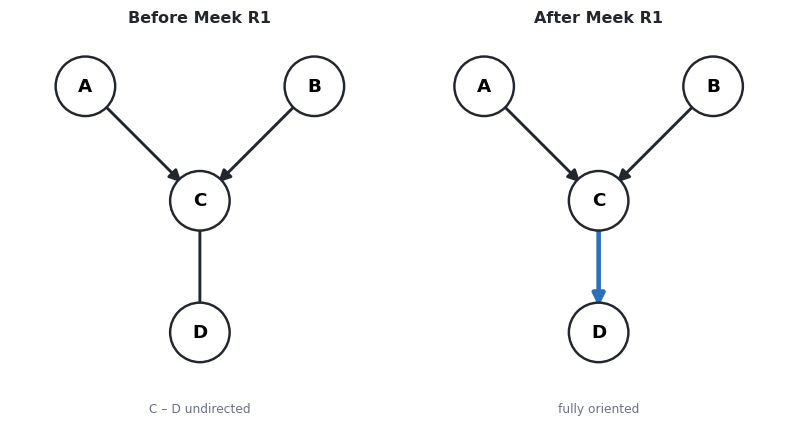

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.9))
draw_state(edges=[("C", "D")], arrows=sorted(arrows - new_arrows),
           title="Before Meek R1", caption="C – D undirected", ax=axes[0])
draw_state(arrows=sorted(arrows - new_arrows), new_arrows=sorted(new_arrows),
           title="After Meek R1", caption="fully oriented", ax=axes[1])
plt.tight_layout()
plt.show()

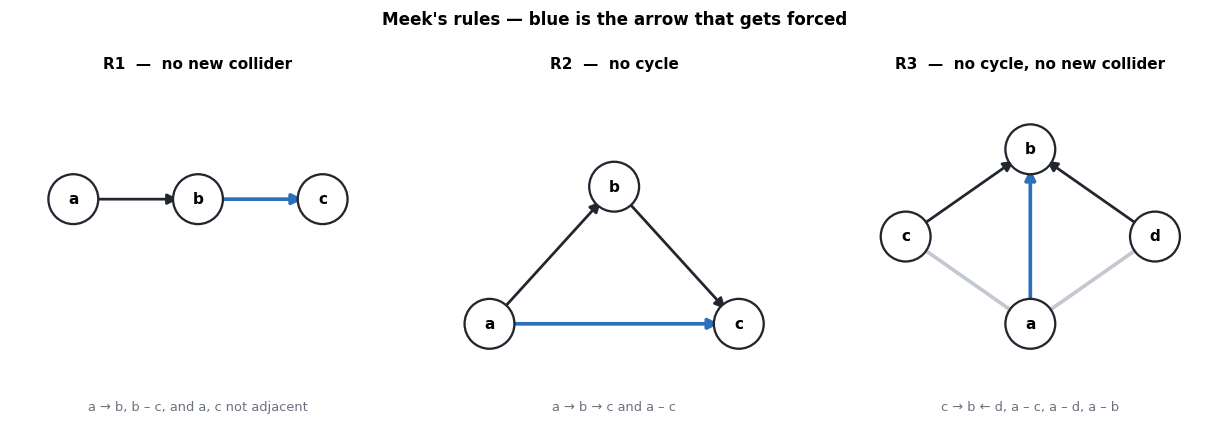

In [23]:
# Meek's three rules, as a reference card.
cards = [
    ("R1  —  no new collider",
     {"a": (0, 1), "b": (1, 1), "c": (2, 1)},
     [("a", "b")], [("b", "c")], [("b", "c")],
     "a → b, b – c, and a, c not adjacent"),
    ("R2  —  no cycle",
     {"a": (0, 0), "b": (1, 1.1), "c": (2, 0)},
     [("a", "b"), ("b", "c")], [("a", "c")], [("a", "c")],
     "a → b → c and a – c"),
    ("R3  —  no cycle, no new collider",
     {"a": (1, 0), "b": (1, 1.4), "c": (0, 0.7), "d": (2, 0.7)},
     [("c", "b"), ("d", "b")], [("a", "c"), ("a", "d"), ("a", "b")], [("a", "b")],
     "c → b ← d, a – c, a – d, a – b"),
]

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.9))
for ax, (title, pos, arcs, und, concl, sub) in zip(axes, cards):
    ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.9, 2.0)
    ax.set_aspect("equal"); ax.axis("off")
    for u, v in und:
        style = "-|>" if (u, v) in concl else "-"
        col = BLUE if (u, v) in concl else GREY
        ax.add_patch(FancyArrowPatch(pos[u], pos[v], arrowstyle=style,
                                     mutation_scale=14, linewidth=2.4, color=col,
                                     shrinkA=13, shrinkB=13, zorder=2))
    for u, v in arcs:
        ax.add_patch(FancyArrowPatch(pos[u], pos[v], arrowstyle="-|>",
                                     mutation_scale=14, linewidth=1.8, color=INK,
                                     shrinkA=13, shrinkB=13, zorder=3))
    for nme, (x, y) in pos.items():
        ax.add_patch(mpatches.Circle((x, y), 0.2, facecolor="white",
                                     edgecolor=INK, linewidth=1.5, zorder=5))
        ax.text(x, y, nme, ha="center", va="center", fontsize=10,
                weight="bold", zorder=6)
    ax.set_title(title, fontsize=10, weight="bold", pad=4)
    ax.text(1, -0.7, sub, ha="center", fontsize=8.5, color="#6b7280")
fig.suptitle("Meek's rules — blue is the arrow that gets forced",
             fontsize=11, weight="bold", y=1.03)
plt.tight_layout()
plt.show()

In [24]:
recovered = set(arrows)
truth = set(TRUE_ARROWS)
assert recovered == truth, f"recovered {recovered} != truth {truth}"
print("Recovered graph:", sorted(recovered))
print("True graph:     ", sorted(truth))
print("\nExact match. PC reconstructed the DAG from 19 CI tests and two rules.")

Recovered graph: [('A', 'C'), ('B', 'C'), ('C', 'D')]
True graph:      [('A', 'C'), ('B', 'C'), ('C', 'D')]

Exact match. PC reconstructed the DAG from 19 CI tests and two rules.


> ### Recap — the whole algorithm
>
> 1. **Start** complete: 6 edges.
> 2. **Depth 0** (6 tests): drop `A–B`, record `sepset(A,B) = {}`.
> 3. **Depth 1** (10 tests): drop `A–D` and `B–D`, both with `sepset = {C}`.
> 4. **Depth 2** (3 tests): nothing falls. **Stop** — no edge has 3 candidate blockers.
>    Skeleton = `A–C`, `B–C`, `C–D`.
> 5. **Colliders**: `A – C – B` is unshielded and `C ∉ sepset(A,B)` ⇒ `A → C ← B`.
> 6. **Meek R1**: `A → C` plus `C – D` with `A`, `D` non-adjacent ⇒ `C → D`.
>
> Each depth ran to completion before any edge was removed — that is the PC-stable
> discipline, and it is why this skeleton does not depend on the order we visited edges.
>
> This example is unusually friendly: its equivalence class collapses to a single DAG, so
> the CPDAG comes out fully directed. Many do not, and PC correctly leaves some edges
> undirected — an honest "I cannot tell from observational data alone" rather than a
> guess.

---

## 9. A compact implementation — and where the shortcuts are

Everything above, assembled. There is nothing conceptually new in it.

> **This is teaching code, not a PC implementation.** Two things to notice. It `break`s at
> the first separator and deletes immediately — that is **original PC, not PC-stable**, so
> its skeleton can in principle depend on edge order. And it is deliberately minimal:
> just the orientation propagation this four-node example needs. Real libraries also
> handle orientation conflicts, the full rule set, background knowledge, missing data, and
> numerical edge cases.

In [25]:
def pc(data, alpha=0.05, names=VARS):
    """Small PC-style teaching implementation for this example."""
    ind = {v: i for i, v in enumerate(names)}
    cit = ParCorrGPU(data, device="cpu")

    def t(x, y, S):
        return float(cit(ind[x], ind[y], [ind[s] for s in S])[0])

    E = {frozenset(e) for e in itertools.combinations(names, 2)}
    sep, depth = {}, 0
    while E:
        nbrs = {v: {w for e in E if v in e for w in e if w != v} for v in names}
        cand = {e: sorted((nbrs[x] | nbrs[y]) - {x, y})
                for e in E for x, y in [sorted(e)]}
        if max(len(c) for c in cand.values()) < depth:
            break                                        # stopping rule
        for e in sorted(E, key=lambda s: sorted(s)):
            x, y = sorted(e)
            for S in itertools.combinations(cand[e], depth):
                if t(x, y, S) > alpha:
                    E.discard(e)
                    sep[e] = set(S)
                    break                                # one blocker is enough
        depth += 1

    arr = set()
    for z in names:                                      # collider rule
        nb = sorted({w for e in E if z in e for w in e if w != z})
        for x, y in itertools.combinations(nb, 2):
            if frozenset((x, y)) not in E and z not in sep.get(frozenset((x, y)), {z}):
                arr |= {(x, z), (y, z)}
    changed = True
    while changed:                                       # Meek R1
        changed = False
        for a, b in list(arr):
            for c in {w for e in E if b in e for w in e if w != b}:
                if c != a and (b, c) not in arr and (c, b) not in arr \
                        and frozenset((a, c)) not in E:
                    arr.add((b, c)); changed = True
    return E, arr, sep


E_, arr_, _ = pc(X)
assert arr_ == truth
print("compact teaching version on the full sample:", sorted(arr_), " -> matches the true DAG")

compact teaching version on the full sample: [('A', 'C'), ('B', 'C'), ('C', 'D')]  -> matches the true DAG


Now the honest part. The p-values you saw were `1e-141`, `1e-302` — absurdly decisive.
That is what 2000 clean samples of a strongly linear system buys you. Real data is not
like that.

Here is the same algorithm on the same system with fewer samples.

 n samples    true arrows found (of 3)    exact DAG
---------------------------------------------------
        30                        0.29          8%
        50                        0.54         17%
       100                        2.07         69%
       300                        2.85         95%
      1000                        2.73         91%
      3000                        2.85         95%


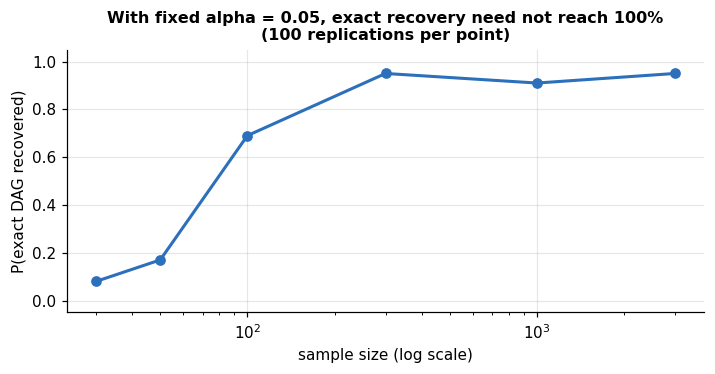

In [26]:
REPS = 100
rows = []
for n_try in [30, 50, 100, 300, 1000, 3000]:
    found, exact = 0, 0
    for rep in range(REPS):
        r = np.random.default_rng(1000 + rep)
        a = r.standard_normal(n_try); b = r.standard_normal(n_try)
        c = a + b + r.standard_normal(n_try)
        d = 1.2 * c + r.standard_normal(n_try)
        _, ar, _ = pc(np.column_stack([a, b, c, d]))
        found += len(ar & truth)
        exact += int(ar == truth)
    rows.append((n_try, found / REPS, exact / REPS))

print(f"{'n samples':>10}{'true arrows found (of 3)':>28}{'exact DAG':>13}")
print("-" * 51)
for n_try, avg, ex in rows:
    print(f"{n_try:>10}{avg:>28.2f}{ex:>12.0%}")

fig, ax = plt.subplots(figsize=(6.6, 3.5))
ax.plot([r[0] for r in rows], [r[2] for r in rows], "o-", color=BLUE, linewidth=2)
ax.set_xscale("log"); ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("sample size (log scale)"); ax.set_ylabel("P(exact DAG recovered)")
ax.set_title(f"With fixed alpha = 0.05, exact recovery need not reach 100%\n"
             f"({REPS} replications per point)", fontsize=10.5, weight="bold")
ax.grid(alpha=0.3); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Two things in that curve are worth sitting with.

**At small `n`, power is the problem.** At `n = 30` real dependencies are hard to tell
from noise, so the skeleton is unstable and exact recovery is rare.

**At large `n`, this experiment still fluctuates below 100%** — because we hold
`alpha = 0.05` fixed. A fixed-level test keeps making occasional false rejections, and PC
chains many decisions together. More data buys power, not a zero-error test. That is a
tuning tradeoff, not proof that PC cannot be consistent: asymptotic arguments let the
threshold shrink with `n`. The practical lesson — `alpha` is not a magic constant, and
one fitted graph is not certainty.

**Two failure modes beyond sample size**

1. **Error propagation.** A wrong deletion changes the adjacency sets, which changes
   which higher-order tests are even available later.
2. **Order dependence.** The original skeleton can depend on the order edges are visited.
   **PC-stable** fixes this by freezing the neighbour sets for a whole depth, running
   every eligible test, and applying all removals only once the depth is finished — the
   `stable=True` argument on `run_cdnots`, on by default. It is also what we did by hand
   in Sections 3–5.

For real work, pair the point estimate with stability checks: vary `alpha`, bootstrap or
subsample, and report which edges survive rather than one graph as fact.

---

## 10. Putting the time axis back

Everything so far was cross-sectional. Now let the same structure unfold over time:

$$A_t = \varepsilon, \quad B_t = \varepsilon, \quad
C_t = A_{t-1} + B_{t-1} + \varepsilon, \quad D_t = 1.2\,C_{t-1} + \varepsilon$$

`causal-ts` handles this with `run_cdnots`, a constraint-based procedure adapted to time
series. The skeleton idea carries over — delete a candidate link when a CI statement
separates it — but the objects tested are lagged copies of variables, and the search
enforces temporal structure. The big change is that temporal order now supplies
orientation information.

In [27]:
from causalts import run_cdnots

T = 2000
r = np.random.default_rng(SEED)
a = r.standard_normal(T)
b = r.standard_normal(T)
c = np.zeros(T)
d = np.zeros(T)
for t in range(1, T):
    c[t] = a[t - 1] + b[t - 1] + r.standard_normal()
    d[t] = 1.2 * c[t - 1] + r.standard_normal()

df_ts = pd.DataFrame({"A": a, "B": b, "C": c, "D": d})
res = run_cdnots(df=df_ts, indep_test=ParCorrGPU(df_ts.values, device="cpu"),
                 num_lags=1, include_C=False, alpha=0.05, stable=True)

d_ = len(VARS)
g = res.cg_tig[:d_, :d_, :]
print("discovered lagged edges:")
for lag in range(g.shape[2]):
    for i in range(d_):
        for j in range(d_):
            if g[i, j, lag]:
                print(f"  {VARS[i]}(t-{lag}) → {VARS[j]}(t)")

discovered lagged edges:
  A(t-1) → C(t)
  B(t-1) → C(t)
  C(t-1) → D(t)


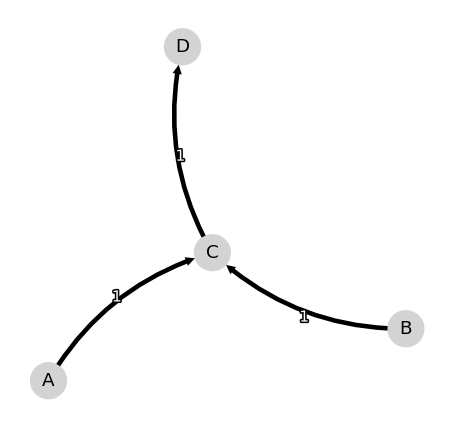

In [28]:
res.plot()
plt.show()

**What changed, and what did not**

- **The skeleton logic carries over** — same CI evidence, same separating sets, now over
  lagged copies of the variables.
- **Lagged edges become easy to orient.** `A(t−1)` and `C(t)` can only connect one way.
  Once we impose that causes cannot run backward in time, the direction is fixed.
- **Contemporaneous edges are still hard.** For interactions inside one time step, time
  tells you nothing and you are back to Section 7 — which is exactly why `run_cdnots`
  still runs the collider rule and Meek's rules.
- **CDNOTS adds one thing this notebook skipped**: a node `C` for the time index, which
  lets it handle systems whose mechanisms *change* over the sample. See the
  [Beginner's Guide, Part 5](beginers_guide.ipynb) and
  [multi-C nonstationarity](multi_c_nonstationarity.ipynb).

---

## Try it yourself

Change one thing at a time, and predict the result before you run it:

1. Set `ALPHA` to `0.01`, then `0.10`. Which kind of error gets easier, and which harder?
2. Weaken `A → C` from `1.0` to `0.2`. At what sample size does that edge become stable?
3. Add an unobserved variable driving both `A` and `B`. Which assumption did you break,
   and which edges go wrong?
4. Swap partial correlation for a nonlinear CI test on nonlinear data. The search logic
   is unchanged; only the evidence is.

---

## Key takeaways

1. PC **deletes**: an edge survives only if nothing can break its dependence.
2. Always record the **separating set** — orientation is impossible without it.
3. Chain and fork are **Markov equivalent**; the unshielded collider is the local pattern
   that tells equivalence classes apart.
4. One collider **propagates** through Meek's rules to orient further edges.
5. PC returns a **CPDAG**, not one DAG. An undirected edge means unresolved orientation,
   not a failed run.

## Where to go next

| you want to | go here |
|---|---|
| See the *other* family solve the same problem | [How Score-Based Discovery Works](score_based_step_by_step.ipynb) |
| Get the conceptual background | [Beginner's Guide](beginers_guide.ipynb) |
| Run all four algorithms on real data | [Getting Started Tutorial](../tutorial.ipynb) |
| Pick a CI test for nonlinear data | [CI test comparison](ci_test_comparison.ipynb) |
| Tell the algorithm what you already know | [Background knowledge](background_knowledge.ipynb) |
| Diagnose hidden confounding | [Latent confounder detection](latent_confounder_detection.ipynb) |
| Turn a discovered graph into an effect estimate | [Effect estimation](effect_estimation.ipynb) |

### References

- Spirtes, Glymour & Scheines, *Causation, Prediction, and Search* — the classical PC
  framework and its assumptions.
- Meek (1995), *Causal inference and causal explanation with background knowledge* —
  orientation rules and background knowledge.
- Colombo & Maathuis (2014), *Order-Independent Constraint-Based Causal Structure
  Learning* — PC-stable and order dependence.